In [1]:
# !conda install pytorch torchvision torchaudio -c pytorch-nightly
# !pip install torch transformers accelerate datasets scikit-learn numpy matplotlib tqdm

import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from tqdm import tqdm
from sklearn.decomposition import PCA
from collections import defaultdict
import math

###############################################################################
# Arguments
###############################################################################
args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "ag_news",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
    ],
    "max_texts": 1000,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "results_multidataset",
    "num_seeds": 3,  # Number of repeated trials for error bars
}
os.makedirs(args["output_dir"], exist_ok=True)

###############################################################################
# 1) Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

###############################################################################
# 2) Vector/Feature-Space Distance Functions
#    (Correlation is removed as requested)
###############################################################################
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def manhattan_distance(x, y):
    return np.sum(np.abs(x - y))

def minkowski_distance(x, y, p=3):
    return np.sum(np.abs(x - y) ** p) ** (1.0 / p)

def chebyshev_distance(x, y):
    return np.max(np.abs(x - y))

def canberra_distance(x, y):
    numerator = np.abs(x - y)
    denominator = np.abs(x) + np.abs(y) + 1e-12
    return np.sum(numerator / denominator)

DISTANCE_FUNCTIONS = {
    "euclidean": euclidean_distance,
    "manhattan": manhattan_distance,
    "minkowski": lambda u, v: minkowski_distance(u, v, p=3),  # example p=3
    "chebyshev": chebyshev_distance,
    "canberra": canberra_distance,
}

###############################################################################
# 3) EmbeddingTracker for Mahalanobis or the simpler distances
###############################################################################
class EmbeddingTracker:
    """
    A tracker that maintains:
    - An exponential-moving-average (EMA) of the embedding mean
    - An exponential-moving-average covariance (for Mahalanobis)
    - A selected distance metric: "mahalanobis" or one from DISTANCE_FUNCTIONS
    """
    def __init__(self, embedding_dim, alpha=0.01, distance_name="mahalanobis"):
        self.alpha = alpha
        self.distance_name = distance_name

        # For all trackers, keep track of the mean.
        self.mean = np.zeros((embedding_dim,))
        self.count = 0

        # Mahalanobis-specific
        self.cov = np.eye(embedding_dim)

    def update(self, embedding):
        """Update the running mean (and covariance, if Mahalanobis)."""
        if self.count == 0:
            self.mean = embedding
            if self.distance_name == "mahalanobis":
                self.cov = np.eye(len(embedding))
        else:
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding

            if self.distance_name == "mahalanobis":
                diff = embedding - self.mean
                self.cov = (1 - self.alpha) * self.cov + self.alpha * np.outer(diff, diff)
        self.count += 1

    def compute_distance(self, embedding):
        """Compute distance between 'embedding' and the tracker's current mean."""
        if self.distance_name == "mahalanobis":
            diff = embedding - self.mean
            cov_inv = np.linalg.pinv(self.cov)
            return np.sqrt(diff.T @ cov_inv @ diff)
        else:
            dist_fn = DISTANCE_FUNCTIONS[self.distance_name]
            return dist_fn(self.mean, embedding)

###############################################################################
# 4) Single-Seed Data Collection
###############################################################################
def collect_data_single_seed(seed):
    """Run the entire process once for a given seed."""
    set_seed(seed)

    # Detect device
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print(f"[Seed={seed}] Using device:", device)

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name  = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col      = dataset_info["text_column"]

        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts    = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name).to(device)
            model.eval()

            # Precompute baseline embeddings
            baseline_embs = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            # Fit PCA on the baseline embeddings
            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)

            key = (dataset_name, model_name)

            # We'll try multiple distances, including Mahalanobis
            all_distance_names = ["mahalanobis"] + list(DISTANCE_FUNCTIONS.keys())

            for distance_name in all_distance_names:
                for drift_strength in args["drift_strengths"]:
                    print(f"[Seed={seed}] Distance={distance_name}, drift_strength={drift_strength} ...")
                    drifted_texts = introduce_gradual_drift(drift_texts, fraction_shuffle=drift_strength)
                    test_texts = baseline_texts + drifted_texts

                    # 1) No PCA
                    embedding_dim_no_pca = baseline_embs.shape[1]
                    tracker_no_pca = EmbeddingTracker(
                        embedding_dim_no_pca,
                        alpha=0.01,
                        distance_name=distance_name
                    )
                    distance_scores_no_pca = []

                    # Initialize tracker with baseline distribution
                    for batch in batch_generator(baseline_texts, args["batch_size"]):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        mean_emb = emb.mean(axis=0)
                        tracker_no_pca.update(mean_emb)

                    # Process the combined test set (baseline + drifted)
                    for batch in tqdm(batch_generator(test_texts, args["batch_size"]), leave=False):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        mean_emb = emb.mean(axis=0)
                        dist = tracker_no_pca.compute_distance(mean_emb)
                        distance_scores_no_pca.append(dist)
                        tracker_no_pca.update(mean_emb)

                    final_dist_no_pca = distance_scores_no_pca[-1] if distance_scores_no_pca else 0.0

                    # 2) With PCA
                    embedding_dim_pca = args["pca_components"]
                    tracker_pca = EmbeddingTracker(
                        embedding_dim_pca,
                        alpha=0.01,
                        distance_name=distance_name
                    )
                    distance_scores_pca = []

                    # Initialize tracker with baseline (reduced)
                    for batch in batch_generator(baseline_texts, args["batch_size"]):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        emb_pca = pca.transform(emb)
                        mean_emb = emb_pca.mean(axis=0)
                        tracker_pca.update(mean_emb)

                    for batch in tqdm(batch_generator(test_texts, args["batch_size"]), leave=False):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        emb_pca = pca.transform(emb)
                        dist = tracker_pca.compute_distance(emb_pca.mean(axis=0))
                        distance_scores_pca.append(dist)
                        tracker_pca.update(emb_pca.mean(axis=0))

                    final_dist_pca = distance_scores_pca[-1] if distance_scores_pca else 0.0

                    # Store results
                    # Key: (dataset_name, model_name)
                    # We'll keep each record in a list.
                    results[key].append({
                        "distance_name": distance_name,
                        "drift_strength": drift_strength,
                        "pca": False,
                        "final_similarity": final_dist_no_pca,
                        "seed": seed,
                    })
                    results[key].append({
                        "distance_name": distance_name,
                        "drift_strength": drift_strength,
                        "pca": True,
                        "final_similarity": final_dist_pca,
                        "seed": seed,
                    })

    return results

###############################################################################
# 5) Collect Data Across Multiple Seeds
###############################################################################
def collect_data_multiple_seeds():
    all_results = defaultdict(list)

    for seed in range(args["num_seeds"]):
        seed_results = collect_data_single_seed(seed)

        # Merge the per-seed results into the master
        for key, records in seed_results.items():
            all_results[key].extend(records)

    print("\nAll seeds complete!")
    return all_results

###############################################################################
# Run the Multi-Seed Experiments
###############################################################################
all_results = collect_data_multiple_seeds()

[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] Distance=mahalanobis, drift_strength=0.0 ...


[Seed=0] Distance=mahalanobis, drift_strength=0.25 ...


[Seed=0] Distance=mahalanobis, drift_strength=0.5 ...


[Seed=0] Distance=mahalanobis, drift_strength=0.75 ...


[Seed=0] Distance=mahalanobis, drift_strength=1.0 ...


...

[Seed=2] Distance=canberra, drift_strength=0.25 ...


[Seed=2] Distance=canberra, drift_strength=0.5 ...


[Seed=2] Distance=canberra, drift_strength=0.75 ...


[Seed=2] Distance=canberra, drift_strength=1.0 ...



All seeds complete!


In [7]:
import pandas as pd

# Flatten all_results into a list of dictionaries
flattened_data = []
for (dataset_name, model_name), records in all_results.items():
    for r in records:
        r["Dataset"] = dataset_name
        r["Model"] = model_name
        flattened_data.append(r)

df = pd.DataFrame(flattened_data)

save_path = os.path.join(args["output_dir"], "all_results_vector_space.csv")
df.to_csv(save_path, index=False)

print(f"Saved all_results to {save_path}")
df.head()

Saved all_results to results_multidataset/all_results_vector_space.csv


,distance_name,drift_strength,pca,final_similarity,seed,Dataset,Model
0,mahalanobis,0.00,False,0.822321,0,yelp_review_full,nlpaueb/sec-bert-base
1,mahalanobis,0.00,True,0.152716,0,yelp_review_full,nlpaueb/sec-bert-base
2,mahalanobis,0.25,False,1.473224,0,yelp_review_full,nlpaueb/sec-bert-base
3,mahalanobis,0.25,True,0.618627,0,yelp_review_full,nlpaueb/sec-bert-base
4,mahalanobis,0.50,False,2.016730,0,yelp_review_full,nlpaueb/sec-bert-base


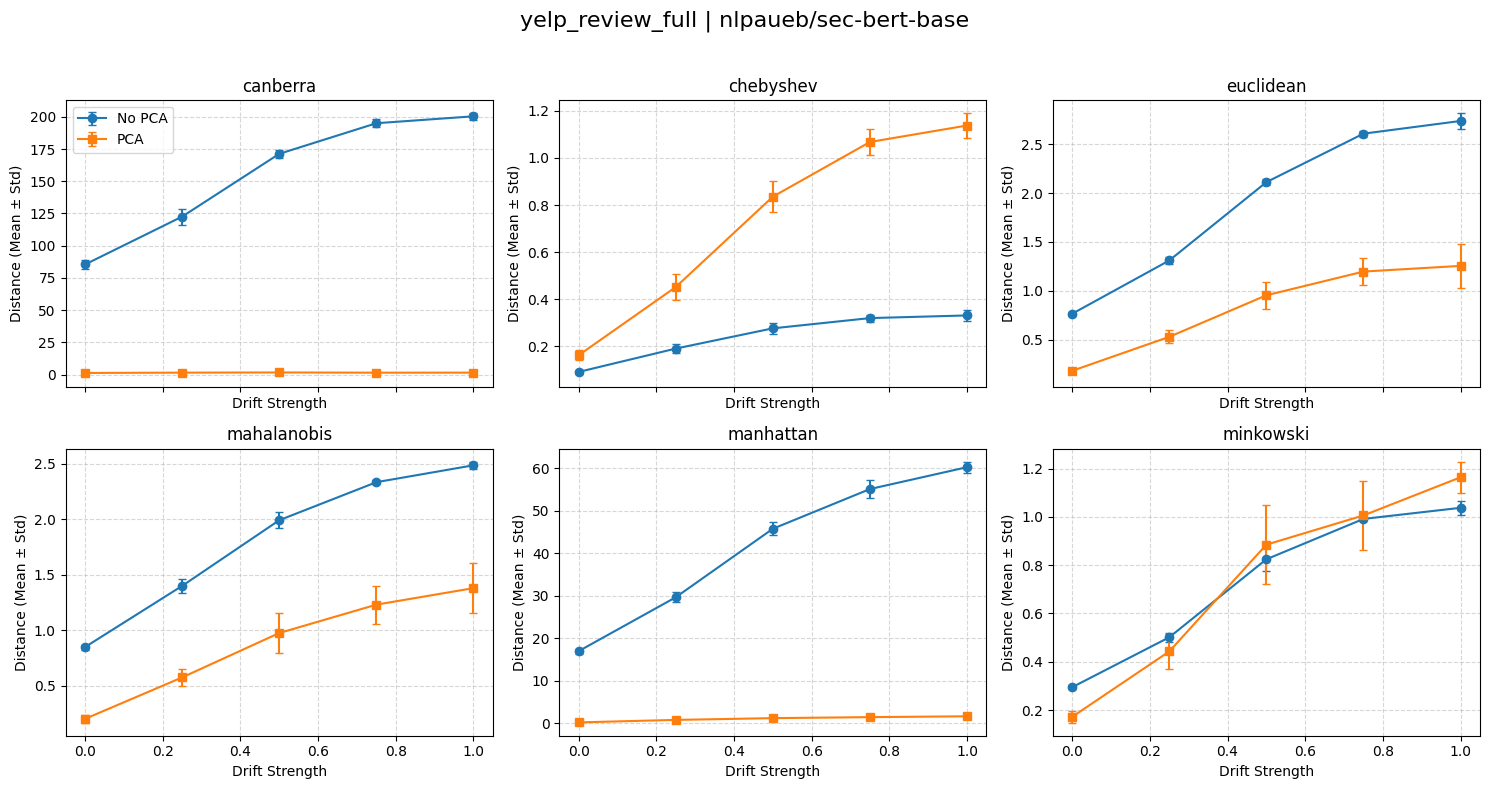

Saved figure: results_multidataset/yelp_review_full_nlpaueb_sec-bert-base_distances_errorbars.png


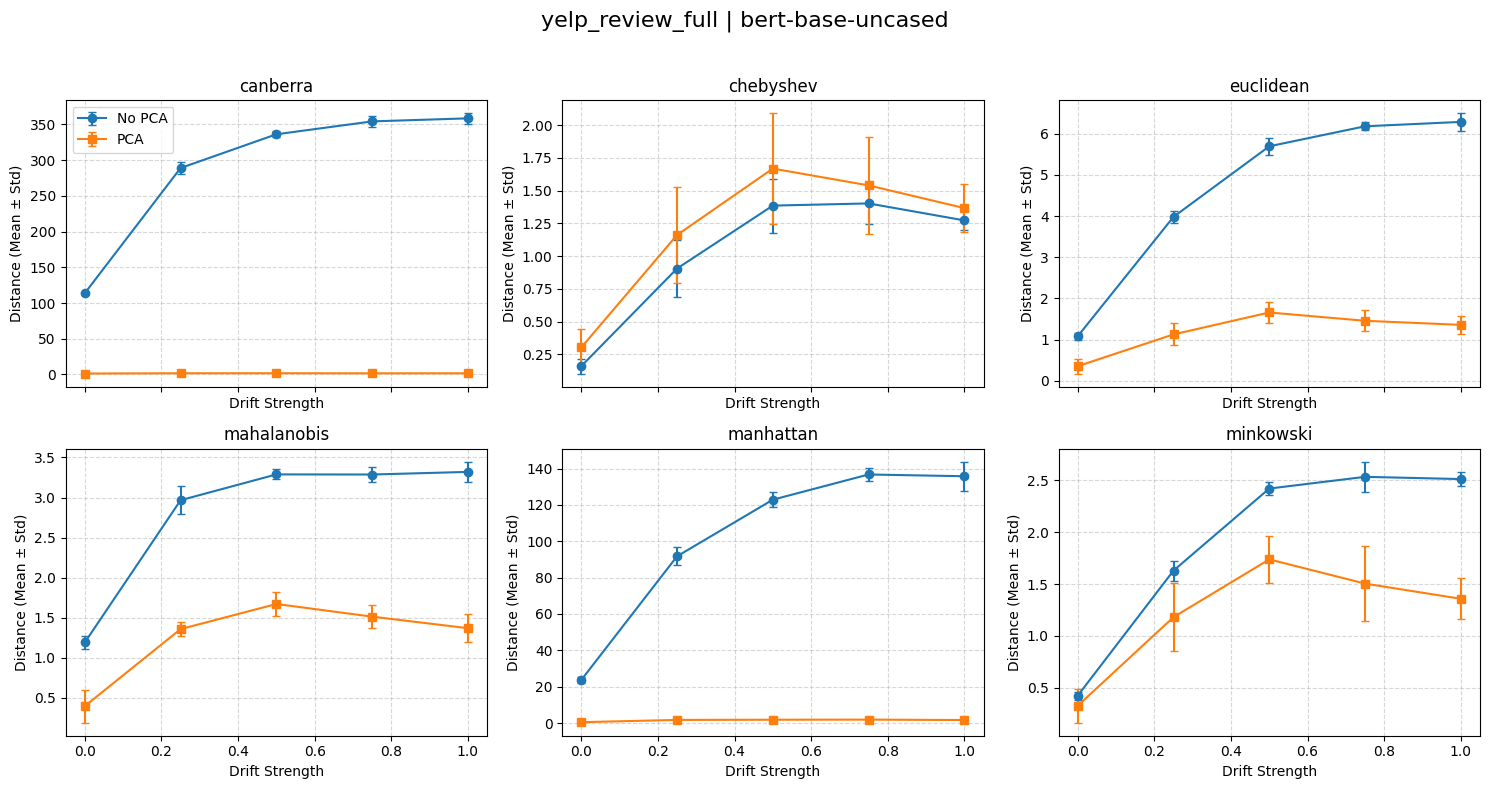

Saved figure: results_multidataset/yelp_review_full_bert-base-uncased_distances_errorbars.png


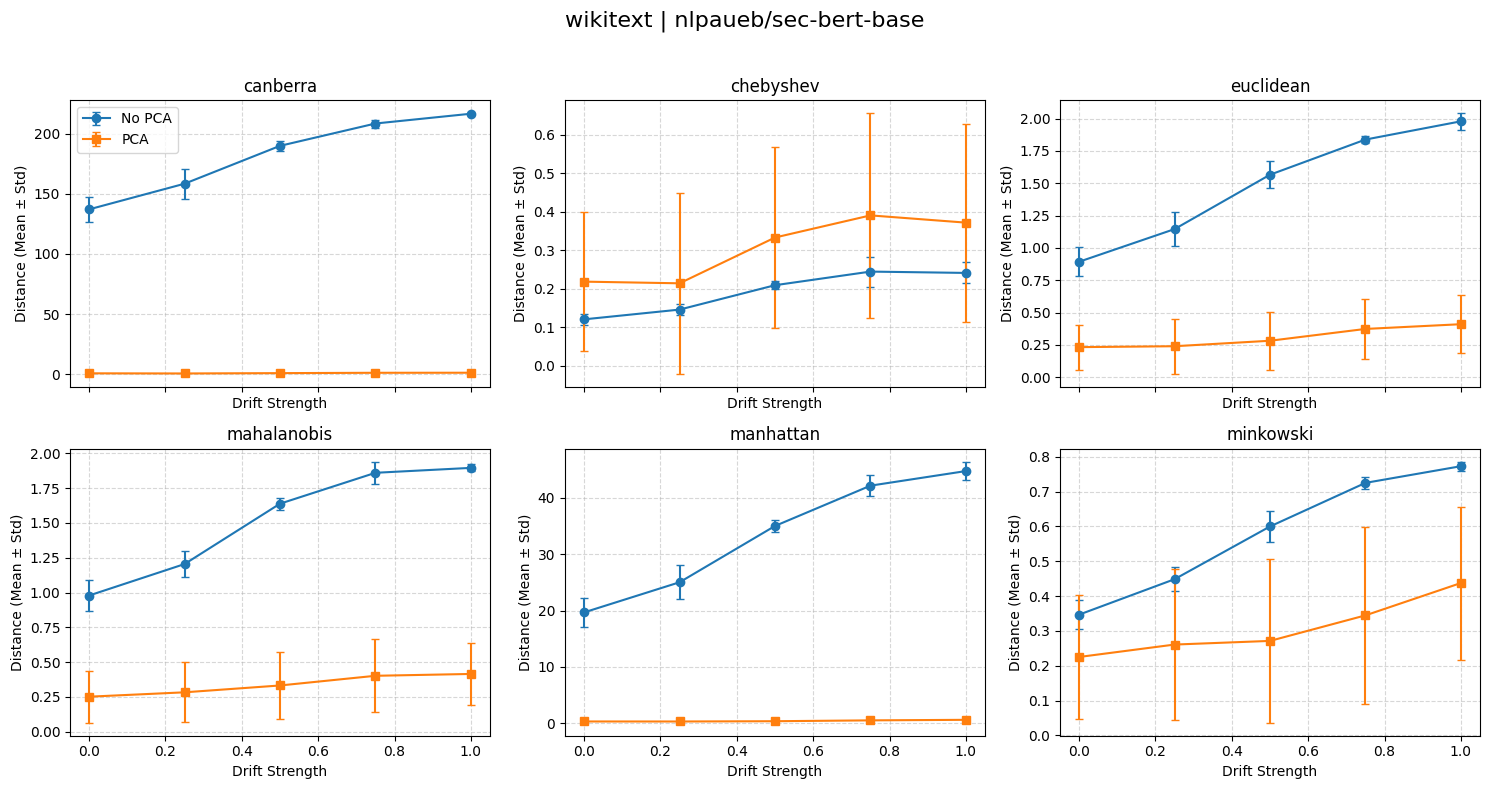

Saved figure: results_multidataset/wikitext_nlpaueb_sec-bert-base_distances_errorbars.png


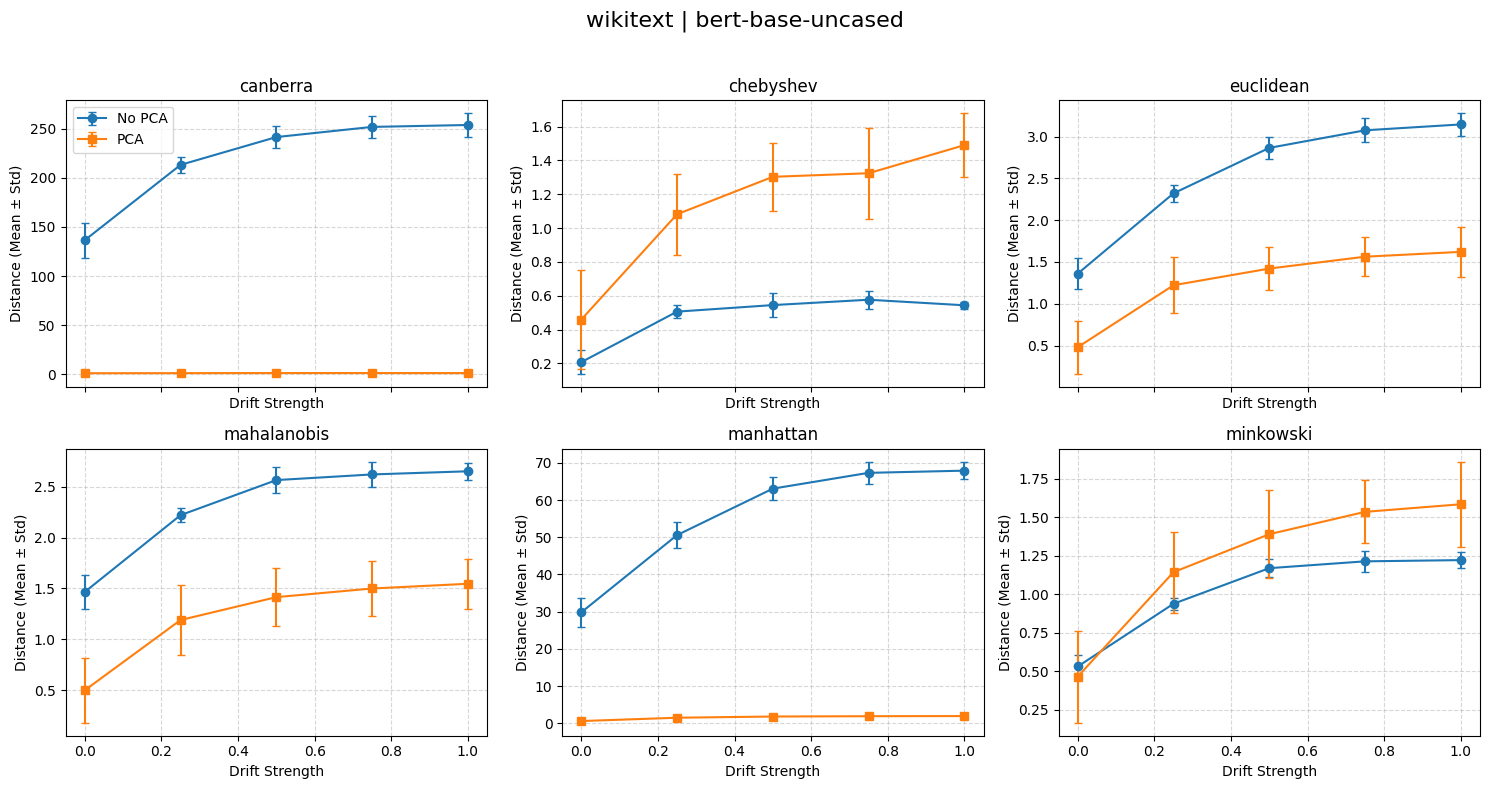

Saved figure: results_multidataset/wikitext_bert-base-uncased_distances_errorbars.png


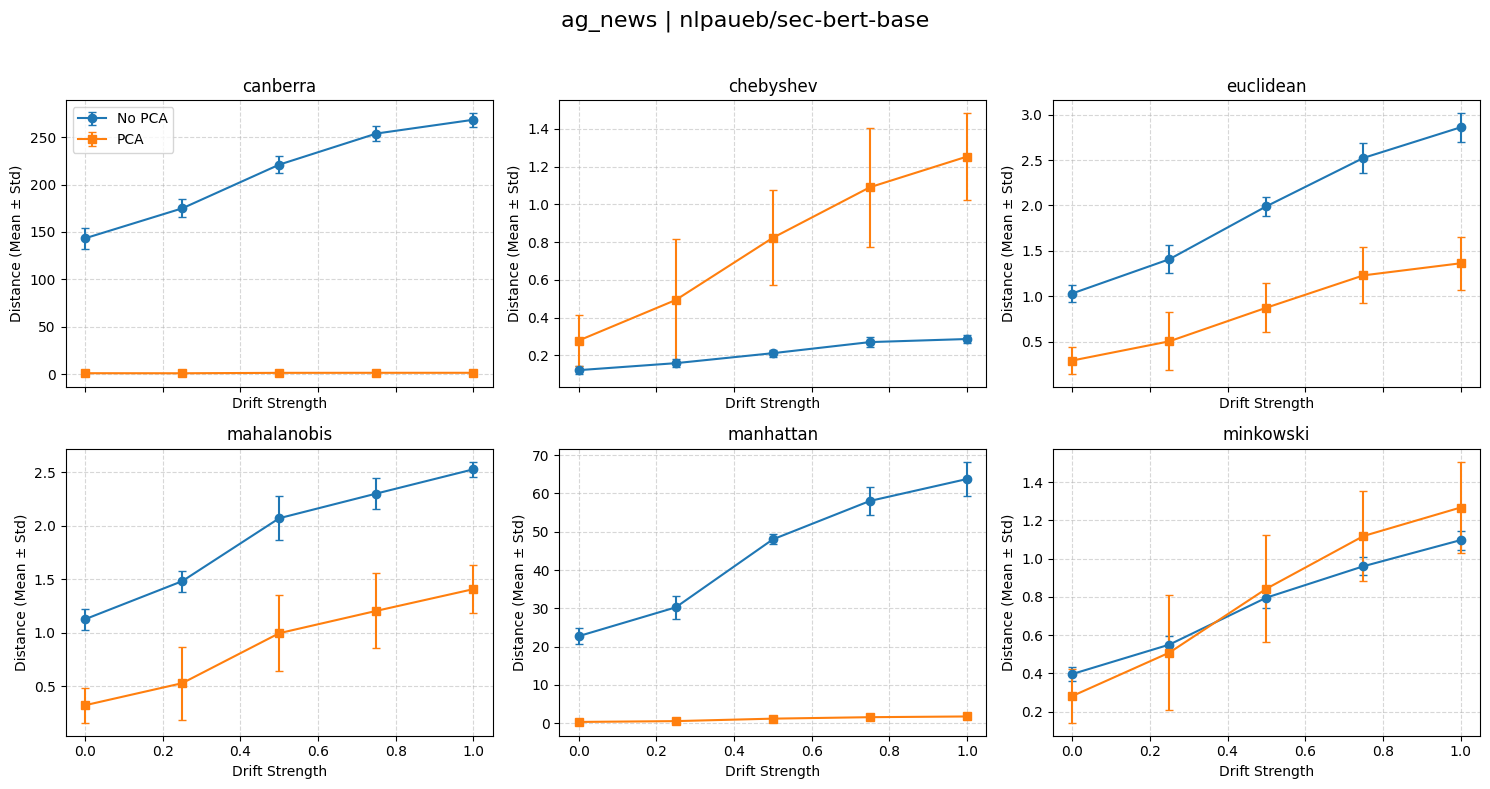

Saved figure: results_multidataset/ag_news_nlpaueb_sec-bert-base_distances_errorbars.png


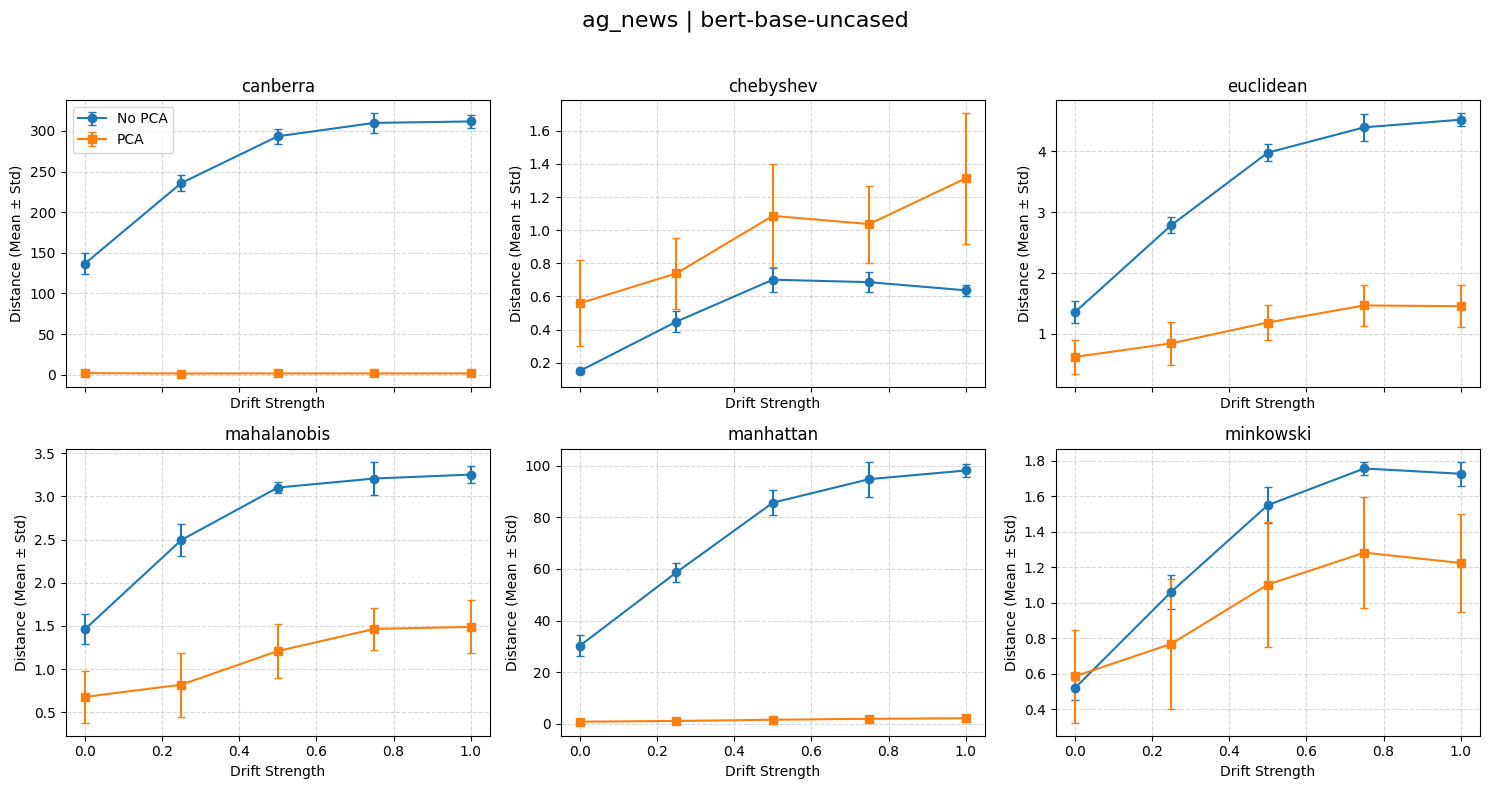

Saved figure: results_multidataset/ag_news_bert-base-uncased_distances_errorbars.png


In [2]:
###############################################################################
# 6) Plot with Error Bars
###############################################################################
def plot_distance_with_error_bars(all_results):
    """
    We aggregate across seeds: For each (dataset_name, model_name, distance_name, pca, drift_strength),
    compute the mean + std of final_distance across seeds.
    Then we plot error bars for each drift_strength for "No PCA" and "PCA" lines.
    """
    from collections import defaultdict

    # aggregated[(dataset_name, model_name, distance_name, pca, drift_strength)]
    # = list of final_distances for different seeds
    aggregator = defaultdict(list)

    for (dataset_name, model_name), records in all_results.items():
        for r in records:
            dist_name = r["distance_name"]
            drift_strength = r["drift_strength"]
            pca_flag = r["pca"]
            final_dist = r["final_similarity"]
            seed = r["seed"]

            key = (dataset_name, model_name, dist_name, pca_flag, drift_strength)
            aggregator[key].append(final_dist)

    # Now compute mean/std
    aggregated_data = []
    for key, dist_values in aggregator.items():
        dataset_name, model_name, dist_name, pca_flag, drift_strength = key
        mean_val = np.mean(dist_values)
        std_val = np.std(dist_values)
        aggregated_data.append({
            "dataset_name": dataset_name,
            "model_name": model_name,
            "distance_name": dist_name,
            "pca": pca_flag,
            "drift_strength": drift_strength,
            "mean_val": mean_val,
            "std_val": std_val
        })

    # Now let's group by (dataset_name, model_name) for plotting
    from collections import defaultdict
    grouped = defaultdict(list)
    for row in aggregated_data:
        ds = row["dataset_name"]
        md = row["model_name"]
        grouped[(ds, md)].append(row)

    for (dataset_name, model_name), rows in grouped.items():
        # Gather all distance names
        dist_names = sorted(set(r["distance_name"] for r in rows))

        # Create subplots
        n_dists = len(dist_names)
        n_cols = 3
        n_rows = math.ceil(n_dists / n_cols)
        fig, axs = plt.subplots(n_rows, n_cols,
                                figsize=(5 * n_cols, 4 * n_rows),
                                sharex=True)
        axs = axs.flatten()
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        for i, dist_name in enumerate(dist_names):
            ax = axs[i]
            # Filter for this dist_name, then separate PCA vs No PCA
            dist_rows = [r for r in rows if r["distance_name"] == dist_name]
            no_pca = [r for r in dist_rows if r["pca"] == False]
            pca = [r for r in dist_rows if r["pca"] == True]

            no_pca_sorted = sorted(no_pca, key=lambda x: x["drift_strength"])
            pca_sorted = sorted(pca, key=lambda x: x["drift_strength"])

            x_no_pca = [r["drift_strength"] for r in no_pca_sorted]
            y_no_pca = [r["mean_val"] for r in no_pca_sorted]
            e_no_pca = [r["std_val"] for r in no_pca_sorted]

            x_pca = [r["drift_strength"] for r in pca_sorted]
            y_pca = [r["mean_val"] for r in pca_sorted]
            e_pca = [r["std_val"] for r in pca_sorted]

            # Plot error bars
            ax.errorbar(x_no_pca, y_no_pca, yerr=e_no_pca,
                        fmt='-o', capsize=3, label="No PCA")

            ax.errorbar(x_pca, y_pca, yerr=e_pca,
                        fmt='-s', capsize=3, label="PCA")

            ax.set_title(dist_name)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance (Mean ± Std)")
            ax.grid(True, linestyle='--', alpha=0.5)
            if i == 0:
                ax.legend()

        # Hide leftover plots if any
        for j in range(i+1, n_rows*n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fname = f"{dataset_name}_{model_name.replace('/', '_')}_distances_errorbars.png"
        save_path = os.path.join(args["output_dir"], fname)
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Saved figure: {save_path}")

plot_distance_with_error_bars(all_results)


In [22]:
# read_

('yelp_review_full', 'nlpaueb/sec-bert-base')
{'distance_name': 'mahalanobis', 'drift_strength': 0.0, 'pca': False, 'final_similarity': 0.8223213395176131, 'seed': 0, 'Dataset': 'yelp_review_full', 'Model': 'nlpaueb/sec-bert-base'}
{'distance_name': 'mahalanobis', 'drift_strength': 0.0, 'pca': True, 'final_similarity': 0.1527158561506707, 'seed': 0, 'Dataset': 'yelp_review_full', 'Model': 'nlpaueb/sec-bert-base'}
{'distance_name': 'mahalanobis', 'drift_strength': 0.25, 'pca': False, 'final_similarity': 1.4732241137660573, 'seed': 0, 'Dataset': 'yelp_review_full', 'Model': 'nlpaueb/sec-bert-base'}
{'distance_name': 'mahalanobis', 'drift_strength': 0.25, 'pca': True, 'final_similarity': 0.6186265034445888, 'seed': 0, 'Dataset': 'yelp_review_full', 'Model': 'nlpaueb/sec-bert-base'}
{'distance_name': 'mahalanobis', 'drift_strength': 0.5, 'pca': False, 'final_similarity': 2.0167304397861194, 'seed': 0, 'Dataset': 'yelp_review_full', 'Model': 'nlpaueb/sec-bert-base'}
{'distance_name': 'mahal

In [24]:
# Integrate PCA and Non-PCA separation into the function

def analyze_drift_measures(all_results, args):
    """
    Enhanced statistical analysis with correctly computed normalization,
    ensuring standard deviation is properly aggregated across all seeds.
    Now includes PCA and Non-PCA separation for vector-based distances.
    """
    summary_data = []

    # Aggregate results across all datasets and models
    for (dataset_name, model_name), records in all_results.items():
        aggregator = {}
        for r in records:
            measure_name = r["distance_name"]
            drift_strength = r["drift_strength"]
            final_dist = r["final_similarity"]
            pca_flag = r.get("pca", False)  # Handle PCA flag if present

            key = (dataset_name, model_name, measure_name, drift_strength, pca_flag)

            if key not in aggregator:
                aggregator[key] = []
            aggregator[key].append(final_dist)

        # Compute mean/std for each drift strength
        for key, values in aggregator.items():
            dataset_name, model_name, measure_name, drift_strength, pca_flag = key
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1)  # ddof=1 ensures sample std deviation

            summary_data.append((dataset_name, model_name, measure_name, drift_strength, mean_val, std_val, pca_flag))

    # Convert to Pandas DataFrame
    df = pd.DataFrame(summary_data, columns=["Dataset", "Model", "Measure", "Drift Strength", "Mean", "Std", "PCA"])

    # Compute percentage increase for each measure, including PCA and Non-PCA
    results_summary = []
    for (measure, pca_flag), measure_df in df.groupby(["Measure", "PCA"]):
        base_mean = measure_df[measure_df["Drift Strength"] == 0.0]["Mean"].mean()
        final_mean = measure_df[measure_df["Drift Strength"] == 1.0]["Mean"].mean()
        base_std = measure_df[measure_df["Drift Strength"] == 0.0]["Std"].mean()
        final_std = measure_df[measure_df["Drift Strength"] == 1.0]["Std"].mean()

        # Prevent division by zero errors
        relative_increase = ((final_mean - base_mean) / abs(base_mean)) * 100 if base_mean != 0 else np.nan
        std_increase = ((final_std - base_std) / abs(base_std)) * 100 if base_std != 0 else np.nan

        results_summary.append({
            "Measure": measure,
            "PCA": "Yes" if pca_flag else "No",
            "Base Mean (Drift 0.0)": round(base_mean, 4),
            "Final Mean (Drift 1.0)": round(final_mean, 4),
            "Std Dev (Avg)": round(measure_df["Std"].mean(), 4),
            "Relative Increase (%)": round(relative_increase, 2),
            "Relative STD Increase (%)": round(std_increase, 2),
        })

    # Convert results summary to DataFrame
    df_summary = pd.DataFrame(results_summary)

    # Ensure that standard deviations are properly computed
    df_summary["Std Dev (Avg)"].replace(0, np.nan, inplace=True)

    # Apply min-max normalization for each column
    for col in ["Std Dev (Avg)", "Relative Increase (%)"]:
        min_val, max_val = df_summary[col].min(), df_summary[col].max()
        if min_val != max_val:  # Avoid division by zero
            df_summary[f"Normalized {col}"] = (df_summary[col] - min_val) / (max_val - min_val)
        else:
            df_summary[f"Normalized {col}"] = 0.0  # If there's no variation, set to 0

    # Sort by highest relative increase
    df_sorted = df_summary.sort_values(by="Normalized Relative Increase (%)", ascending=False)

    # Display table interactively
    print(df_sorted)

    # Save to CSV for further analysis
    save_path = os.path.join(args["output_dir"], "fully_normalized_drift_measure_summary.csv")
    df_sorted.to_csv(save_path, index=False)
    print(f"Saved fully normalized summary table to: {save_path}")

# The function is now modified to handle PCA and Non-PCA separately. Let me know if you want me to run it with data. 🚀
analyze_drift_measures(all_results, args)

        Measure  PCA  Base Mean (Drift 0.0)  Final Mean (Drift 1.0)  \
2     chebyshev   No                 0.1420                  0.5522   
9     manhattan  Yes                 0.4558                  1.6225   
3     chebyshev  Yes                 0.3301                  1.1554   
5     euclidean  Yes                 0.3606                  1.2440   
11    minkowski  Yes                 0.3426                  1.1723   
10    minkowski   No                 0.4186                  1.3942   
4     euclidean   No                 1.0813                  3.5877   
8     manhattan   No                23.8527                 78.4250   
7   mahalanobis  Yes                 0.3913                  1.2676   
6   mahalanobis   No                 1.1786                  2.6889   
0      canberra   No               125.5214                268.2120   
1      canberra  Yes                 1.2919                  1.4926   

    Std Dev (Avg)  Relative Increase (%)  Relative STD Increase (%)  \
2    

/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_10255/2150342610.py:63: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_summary["Std Dev (Avg)"].replace(0, np.nan, inplace=True)


In [25]:
# read the csv all_results_vector_space.csv

df2 = pd.read_csv("results_multidataset/all_results_vector_space.csv")
df2.head()

,distance_name,drift_strength,pca,final_similarity,seed,Dataset,Model
0,mahalanobis,0.00,False,0.822321,0,yelp_review_full,nlpaueb/sec-bert-base
1,mahalanobis,0.00,True,0.152716,0,yelp_review_full,nlpaueb/sec-bert-base
2,mahalanobis,0.25,False,1.473224,0,yelp_review_full,nlpaueb/sec-bert-base
3,mahalanobis,0.25,True,0.618627,0,yelp_review_full,nlpaueb/sec-bert-base
4,mahalanobis,0.50,False,2.016730,0,yelp_review_full,nlpaueb/sec-bert-base


In [27]:
import os
import numpy as np
import pandas as pd

def analyze_drift_measures(all_results, args):
    """
    Enhanced statistical analysis, aggregating over multiple seeds correctly 
    and comparing drift_strength=0.0 vs drift_strength=1.0.
    """

    summary_data = []

    # 1) Aggregate results by (dataset, model, measure, drift_strength, pca)
    for (dataset_name, model_name), records in all_results.items():
        aggregator = {}
        for r in records:
            measure_name = r["distance_name"]
            drift_strength = r["drift_strength"]
            final_dist = r["final_similarity"]
            pca_flag = r.get("pca", False)  # Handle PCA flag if present

            key = (dataset_name, model_name, measure_name, drift_strength, pca_flag)
            aggregator.setdefault(key, []).append(final_dist)

        # 2) Compute mean/std across seeds for each key
        for key, values in aggregator.items():
            dataset_name, model_name, measure_name, drift_strength, pca_flag = key

            # Mean & STD across seeds (sample std => ddof=1)
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1)  # If there's only 1 seed in that group, std=NaN

            summary_data.append(
                (dataset_name, model_name, measure_name, drift_strength,
                 mean_val, std_val, pca_flag)
            )

    # Convert to DataFrame
    df = pd.DataFrame(
        summary_data,
        columns=["Dataset", "Model", "Measure", "Drift Strength", "Mean", "Std", "PCA"]
    )

    # 3) Compute relative increase by grouping per (Dataset, Model, Measure, PCA)
    results_summary = []
    # We define which drift strengths to consider as base vs final
    base_strength = 0.0
    final_strength = 1.0  # adjust if your max drift is e.g. 0.50 instead

    group_cols = ["Dataset", "Model", "Measure", "PCA"]
    for (ds, mdl, measure, pca_flag), group_df in df.groupby(group_cols):
        # Extract base row
        base_row = group_df[group_df["Drift Strength"] == base_strength]
        # Extract final row
        final_row = group_df[group_df["Drift Strength"] == final_strength]

        # If either is missing, skip the comparison
        if base_row.empty or final_row.empty:
            continue

        # Because aggregator compresses all seeds for that (drift_strength) into a single row,
        # there should be exactly 1 row for base, 1 for final. 
        base_mean = base_row["Mean"].iloc[0]
        base_std = base_row["Std"].iloc[0]
        final_mean = final_row["Mean"].iloc[0]
        final_std = final_row["Std"].iloc[0]

        # Compute relative increase for mean
        if base_mean != 0:
            relative_increase = ((final_mean - base_mean) / abs(base_mean)) * 100
        else:
            relative_increase = np.nan

        # Compute relative increase for std
        if base_std != 0 and not np.isnan(base_std):
            std_increase = ((final_std - base_std) / abs(base_std)) * 100
        else:
            std_increase = np.nan

        # Average STD over all drift strengths in this group, 
        # or just show base/final if you prefer
        avg_std = group_df["Std"].mean()

        results_summary.append({
            "Dataset": ds,
            "Model": mdl,
            "Measure": measure,
            "PCA": "Yes" if pca_flag else "No",
            f"Base Mean (Drift {base_strength})": round(base_mean, 4),
            f"Final Mean (Drift {final_strength})": round(final_mean, 4),
            "Std Dev (Avg)": round(avg_std, 4),
            "Relative Increase (%)": round(relative_increase, 2),
            "Relative STD Increase (%)": round(std_increase, 2),
        })

    # 4) Convert results summary to DataFrame
    df_summary = pd.DataFrame(results_summary)

    # If you want to avoid zero or tiny values messing up normalization:
    df_summary["Std Dev (Avg)"].replace(0, np.nan, inplace=True)

    # 5) Optional: Apply min-max normalization for the numeric columns
    #    Typically you might not want to normalize the means themselves,
    #    so let's just normalize "Std Dev (Avg)" and "Relative Increase (%)".
    for col in ["Std Dev (Avg)", "Relative Increase (%)"]:
        if col not in df_summary.columns:
            continue

        min_val = df_summary[col].min()
        max_val = df_summary[col].max()
        col_norm = f"Normalized {col}"
        if pd.isna(min_val) or pd.isna(max_val) or min_val == max_val:
            df_summary[col_norm] = 0.0
        else:
            df_summary[col_norm] = (df_summary[col] - min_val) / (max_val - min_val)

    # 6) Sort by highest normalized relative increase
    sort_col = "Normalized Relative Increase (%)"
    if sort_col in df_summary.columns:
        df_sorted = df_summary.sort_values(by=sort_col, ascending=False)
    else:
        # Fallback sort if normalized column doesn't exist
        df_sorted = df_summary.sort_values(by="Relative Increase (%)", ascending=False)

    # Show final table
    print(df_sorted)

    # 7) Save to CSV for further analysis
    save_path = os.path.join(args["output_dir"], "fully_normalized_drift_measure_summary.csv")
    df_sorted.to_csv(save_path, index=False)
    print(f"Saved fully normalized summary table to: {save_path}")

# Run the analysis function
analyze_drift_measures(all_results, args)

             Dataset                  Model      Measure  PCA  \
50  yelp_review_full      bert-base-uncased    chebyshev   No   
69  yelp_review_full  nlpaueb/sec-bert-base    manhattan  Yes   
65  yelp_review_full  nlpaueb/sec-bert-base    euclidean  Yes   
63  yelp_review_full  nlpaueb/sec-bert-base    chebyshev  Yes   
67  yelp_review_full  nlpaueb/sec-bert-base  mahalanobis  Yes   
..               ...                    ...          ...  ...   
13           ag_news  nlpaueb/sec-bert-base     canberra  Yes   
49  yelp_review_full      bert-base-uncased     canberra  Yes   
61  yelp_review_full  nlpaueb/sec-bert-base     canberra  Yes   
25          wikitext      bert-base-uncased     canberra  Yes   
1            ag_news      bert-base-uncased     canberra  Yes   

    Base Mean (Drift 0.0)  Final Mean (Drift 1.0)  Std Dev (Avg)  \
50                 0.1607                  1.2735         0.1746   
69                 0.2142                  1.6473         0.2454   
65             

/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_10255/2305841183.py:100: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_summary["Std Dev (Avg)"].replace(0, np.nan, inplace=True)


In [32]:
def analyze_drift_measures(all_results, args):
    """
    Aggregates drift measures:
    - Separates PCA vs. Non-PCA results
    - Combines seeds to compute mean and standard deviation
    - Clusters models and datasets together
    - Computes relative increase in drift measures from strength 0.0 to 1.0
    """
    summary_data = []
    
    # Aggregate results across datasets and models
    for (dataset_name, model_name), records in all_results.items():
        aggregator = {}
        for r in records:
            key = (
                dataset_name,
                model_name,
                r["distance_name"],
                r["drift_strength"],
                r.get("pca", False)
            )
            aggregator.setdefault(key, []).append(r["final_similarity"])

        # Compute mean/std for each drift strength
        for key, values in aggregator.items():
            dataset_name, model_name, measure_name, drift_strength, pca_flag = key
            summary_data.append(
                (dataset_name, model_name, measure_name, drift_strength, np.mean(values), np.std(values, ddof=1), pca_flag)
            )

    # Convert to Pandas DataFrame
    df = pd.DataFrame(
        summary_data,
        columns=["Dataset", "Model", "Measure", "Drift Strength", "Mean", "Std", "PCA"]
    )

    # Compute percentage increase for each measure, including PCA and Non-PCA
    results_summary = []
    for (measure, pca_flag), measure_df in df.groupby(["Measure", "PCA"]):
        base_mean = measure_df[measure_df["Drift Strength"] == 0.0]["Mean"].mean()
        final_mean = measure_df[measure_df["Drift Strength"] == 1.0]["Mean"].mean()
        base_std = measure_df[measure_df["Drift Strength"] == 0.0]["Std"].mean()
        final_std = measure_df[measure_df["Drift Strength"] == 1.0]["Std"].mean()

        relative_increase = ((final_mean - base_mean) / abs(base_mean)) * 100 if base_mean != 0 else np.nan
        std_increase = ((final_std - base_std) / abs(base_std)) * 100 if base_std != 0 else np.nan

        results_summary.append({
            "Measure": measure,
            "PCA": "Yes" if pca_flag else "No",
            "Base Mean (Drift 0.0)": round(base_mean, 4),
            "Final Mean (Drift 1.0)": round(final_mean, 4),
            "Std Dev (Avg)": round(measure_df["Std"].mean(), 4),
            "Relative Increase (%)": round(relative_increase, 2),
            "Relative STD Increase (%)": round(std_increase, 2),
        })

    # Convert results summary to DataFrame
    df_summary = pd.DataFrame(results_summary)

    # Replace zero standard deviation with NaN to prevent division errors
    df_summary["Std Dev (Avg)"].replace(0, np.nan, inplace=True)

    # Normalize selected columns
    for col in ["Std Dev (Avg)", "Relative Increase (%)"]:
        min_val, max_val = df_summary[col].min(), df_summary[col].max()
        df_summary[f"Normalized {col}"] = (df_summary[col] - min_val) / (max_val - min_val) if min_val != max_val else 0.0

    # Sort by highest relative increase
    df_sorted = df_summary.sort_values(by="Normalized Relative Increase (%)", ascending=False)
    
    # Save to CSV
    save_path = os.path.join(args["output_dir"], "fully_normalized_drift_measure_summary.csv")
    df_sorted.to_csv(save_path, index=False)
    print(f"Saved fully normalized summary table to: {save_path}")
    
    print(df_sorted)
    
    return df_sorted

# Run the analysis function
df_summary = analyze_drift_measures(all_results, args)

Saved fully normalized summary table to: results_multidataset/fully_normalized_drift_measure_summary.csv
        Measure  PCA  Base Mean (Drift 0.0)  Final Mean (Drift 1.0)  \
2     chebyshev   No                 0.1420                  0.5522   
9     manhattan  Yes                 0.4558                  1.6225   
3     chebyshev  Yes                 0.3301                  1.1554   
5     euclidean  Yes                 0.3606                  1.2440   
11    minkowski  Yes                 0.3426                  1.1723   
10    minkowski   No                 0.4186                  1.3942   
4     euclidean   No                 1.0813                  3.5877   
8     manhattan   No                23.8527                 78.4250   
7   mahalanobis  Yes                 0.3913                  1.2676   
6   mahalanobis   No                 1.1786                  2.6889   
0      canberra   No               125.5214                268.2120   
1      canberra  Yes                 1.2919

/var/folders/_3/jggbxqpj77x_m8nr3ll39p5r0000gn/T/ipykernel_10255/1758863117.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_summary["Std Dev (Avg)"].replace(0, np.nan, inplace=True)
